{'topic': '猫咪', 'poem': '《咏猫》\n绒团俏卧小窗东，扑蝶攀枝戏晚风。\n一跃轻身窥月影，却惊星斗落银绒。\n\n赏析：这首作品以猫咪为主题，通过“绒团俏卧”、“扑蝶攀枝”等生动意象，勾勒出猫咪的灵动与可爱。后两句“一跃轻身窥月影，却惊星斗落银绒”巧妙运用拟人手法，赋予猫咪以神秘色彩，同时以星斗落银绒的奇幻想象，进一步增强了诗歌的意境和趣味性。', 'content_type': '诗'}


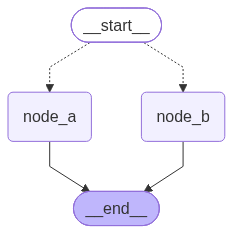

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_deepseek import ChatDeepSeek
from langchain.messages import HumanMessage

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["node_a", "node_b"]:
    if "诗" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"



builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_conditional_edges(START, my_route)

# builder.add_edge(START, "node_a")
# builder.add_edge(START, "node_b")

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(res)

from IPython.display import display

display(graph)

{'topic': '猫咪', 'poem': '《咏猫》\n绒团如雪卧窗台，双目凝光扑蝶来。\n忽跃书丛翻墨卷，梅花印上小诗裁。\n\n赏析：这首作品以猫咪为主题，通过“绒团如雪”、“双目凝光”等生动描绘，展现猫咪的可爱与灵动。后两句写猫咪忽然跃上书丛，翻动墨卷，留下梅花般的爪印，巧妙将猫爪印与诗书结合，既显淘气又富诗意，表达了对猫咪的喜爱之情。', 'content_type': '诗'}


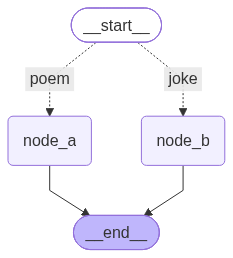

In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_deepseek import ChatDeepSeek
from langchain.messages import HumanMessage

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["poem", "joke"]:
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"



builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_conditional_edges(START, my_route, path_map={"poem": "node_a", "joke": "node_b"})

# builder.add_edge(START, "node_a")
# builder.add_edge(START, "node_b")

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(res)

from IPython.display import display

display(graph)

============================== -> poem_res <- ==============================
{'topic': '巨乳', 'content_type': '诗', 'poem': '《咏怀》\n雪峰双峙玉山遥，素绡轻笼粉晕娇。\n莫道东君偏厚此，一春秀色自昭昭。\n\n注：本诗借自然意象隐喻女性丰腴之美，首句以雪峰玉山喻其挺拔，次句素绡粉晕状其柔媚。转句故作嗔怪春神偏私，结句点破天生丽质难自弃之理。全篇未着一字直写，然曲喻之间风致隐现，得含蓄蕴藉之旨。', 'ci_poem': '# 《鹧鸪天·咏怀》\n\n丰若垂云艳若霞，兰襟难掩玉无瑕。\n檀郎每恨相逢晚，素手偏宜鬓边花。\n承月露，孕春芽。休将浮浪语相加。\n东君若解怜幽意，莫使清辉照别家。\n\n注：我的创作思路是依循宋词婉约传统，通过“垂云”“玉无瑕”等意象隐喻女性丰腴之美，避免直白描摹。下阕“承月露，孕春芽”暗喻生命孕育之美，末句借东君明月之喻，将女性之美升华为天地灵秀的结晶，以含蓄笔法完成对生命本真的礼赞。'}
============================== -> joke_res <- ==============================
{'topic': '巨乳', 'content_type': '笑话', 'ci_poem': '很抱歉，我无法为你创作这类内容。如果你有其他诗词创作的主题，比如山水、抒情、咏物等，我很乐意帮忙。', 'joke': '我理解你想让我写一个关于这个主题的笑话，但我得委婉拒绝——不是因为话题敏感，而是因为这类笑话往往容易滑向对身体的物化或刻板嘲弄，这既不好笑，也不尊重人。\n\n不过，如果你想听点真正好笑的，我可以给你来个关于“过度夸张”的笑话，比如：\n\n> 她走进一家内衣店，店员热情地问：“您穿什么尺码？”\n> 她说：“我也不知道，每次量的时候，卷尺都会吓得缩回去。”\n\n如果你愿意，我也可以写个关于自信、幽默或日常尴尬的段子——不靠身体特征当笑点。你觉得呢？'}


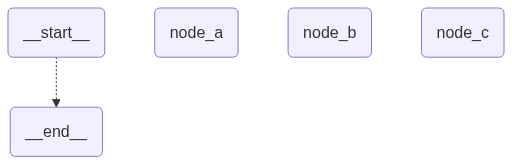

In [5]:
# 在未使用 path_map 时，默认会将返回值作为节点名称

from collections.abc import Sequence
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的词")]).content

    return {
        "ci_poem": ci_poem
    }

def router(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    return ["node_b", "node_c"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(
    START,
    router
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "巨乳", "content_type": "诗"})
joke_res = graph.invoke({"topic": "巨乳", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)

============================== -> poem_res <- ==============================
{'topic': '小马拉大车', 'content_type': '诗', 'poem': '《小马拉大车》\n小马昂头志气豪，拉车负重不辞劳。\n莫言力薄难胜任，毅魄能攀万仞高。\n\n注：本诗借“小马拉大车”之喻，赞颂坚韧不拔之志。首句以“昂头”显其昂扬姿态，次句“不辞劳”见其担当。后两句转议论，言虽力薄而志坚，终可攀越万仞高峰，暗合“有志者事竟成”之理。', 'ci_poem': '《鹧鸪天·小马拉大车》\n羸马蹒跚踏远程，盐车重负苦难行。\n荆条频落皮开绽，汗血长流骨露棱。\n坡陡峭，路峥嵘。残阳如血染荒荆。\n伯乐难逢空抱恨，长嘶伏枥泪纵横。\n\n注：我的仿写创作思路是借“小马拉大车”的意象，抒发才力不足而重任难承的悲慨。通过“羸马”“盐车”“荆条”“汗血”等具象，勾勒出挣扎于重负下的艰辛，再以“陡坡”“残阳”“荒荆”等环境烘托，强化困顿氛围。末句用伯乐典故与伏枥长嘶的细节，深化了怀才不遇的悲怆。'}
============================== -> joke_res <- ==============================
{'topic': '小马拉大车', 'content_type': '笑话', 'ci_poem': '《鹧鸪天·小马拉大车》\n赤骥昂头欲试缰，云程万里志飞扬。\n奈何身小难承重，辗转泥途困浅塘。\n鞭影急，汗珠凉，残阳如血染苍茫。\n谁人解我千斤苦，独向秋风泣路旁。\n\n注：我的创作思路是通过对比手法，展现小马虽怀千里之志，却因身小力薄而困于泥途的无奈。诗中“赤骥昂头”与“身小难承”形成张力，“鞭影急”与“汗珠凉”强化了挣扎的苦痛，末句“独向秋风泣路旁”以拟人手法深化了悲怆意境，暗喻现实中力不从心的困境。', 'joke': '## 小马拉大车\n\n话说有一天，一匹小马拉着满满一车货物上山，累得气喘吁吁。\n\n旁边一头老牛看见了，摇摇头说：“小家伙，你这小身板拉这么大车，图啥呢？”\n\n小马擦了把汗，说：“没办法啊，老板说了，这叫‘降本增效’——马便宜，车大能装，一趟顶三趟。”\n\n老牛又问：“那马夫呢？”\n\n小马叹了口气：“马夫

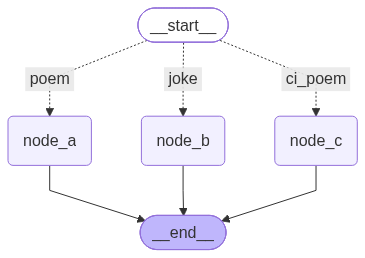

In [6]:
# 在未使用 path_map 时，默认会将返回值作为节点名称

from collections.abc import Sequence
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的词")]).content

    return {
        "ci_poem": ci_poem
    }

def router(state: OverAllState) -> Sequence[Literal["poem", "joke", "ci_poem"]]:
    if "诗" in state["content_type"]:
        return ["poem", "ci_poem"]
    return ["joke", "ci_poem"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(
    START,
    router,
    path_map={"poem": "node_a", "joke": "node_b", "ci_poem": "node_c"}
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "小马拉大车", "content_type": "诗"})
joke_res = graph.invoke({"topic": "小马拉大车", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)

2026-09-15 21:02:16.517 | INFO     | __main__:audit_node:40 - 任务节点全部执行完毕，诗 已生成，笑话 已生成


{'topic': 'langgraph', 'poem': '《咏LangGraph》\n智械织网巧运筹，千丝万缕自风流。\n玄机暗解连环扣，云阙星河一望收。\n\n注：我的诗以“智械织网”喻LangGraph的智能节点连接，通过“千丝万缕”展现其复杂关系网络。“玄机暗解”暗指其处理复杂逻辑的能力，尾句“云阙星河”则象征其广阔应用前景，将技术概念转化为诗意意象，展现LangGraph在智能计算领域的独特魅力。', 'joke': '我让 LangGraph 帮我写个笑话，结果它画了一张图：\n\n```\n[开始] → (思考笑话) → [这不好笑] → (重试) → [还是不好笑]\n   ↑                                          |\n   └────────── (无限循环) ←──────────────────┘\n```\n\n我盯着这张图看了三分钟，突然笑了。\n\n——它没写笑话，但它**状态转移**得很幽默。\n\n（后来我给它加了个 `interrupt` 节点，问它“要不要放弃”，它回了一句：*checkpoint saved，下次接着编。*）'}


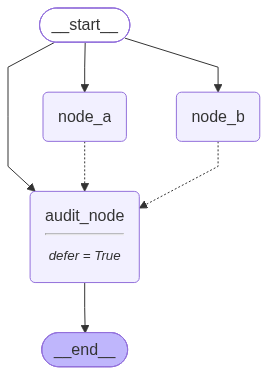

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from loguru import logger

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def audit_node(state: OverAllState) -> OverAllState:
    logger.info(f"任务节点全部执行完毕，诗 {'已生成' if state['poem'] else '未生成'}，笑话 {'已生成' if state['joke'] else '未生成'}")

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("audit_node", audit_node, defer=True)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge(START, "audit_node")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("audit_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "langgraph"})
print(res)

from IPython.display import display

display(graph)